## Variance in Linear Regression

The goal of this notebook is to show how various levels of variance in the dataset can affect the performance of a linear regression model trained with SGD.

In [70]:
import numpy as np

SLOPE = 3.5
INTERCEPT = 7.1

"""Signal to estimate"""
def f(x: np.ndarray) -> np.ndarray:
    return x*SLOPE + INTERCEPT

coefs = np.array([
    [SLOPE],
    [INTERCEPT]
])

In [71]:
"""Generate dataset helper"""

import numpy as np

MIN = -7
MAX = 7
SEED = 777

def generate_dataset(size: int, sample_size: int, noise_upto: float) -> np.ndarray:
    rng = np.random.default_rng(SEED)
    x = rng.uniform(MIN, MAX, sample_size)
    y = f(x)
    y_noise = None

    datasets: list[np.ndarray] = []

    for noise in np.linspace(0, noise_upto, size):
        y_noise = y + rng.standard_normal(x.shape[0]) * noise
        sample = np.stack([x, y_noise]).T

        datasets.append(sample)

    return np.stack(datasets[:])

In [72]:
"""Plot data helper"""

from matplotlib.figure import Figure
import matplotlib.pyplot as plt

def generate_axs(dataset_size: np.ndarray, axis:int = 0) -> tuple[Figure, np.ndarray]:
    row = int(np.floor(np.sqrt(dataset_size)))
    col = int(np.ceil(dataset_size/row))    
    fig, axs = plt.subplots(row, col, figsize=(16, 7))

    return fig, axs

def scatter_dataset(X:np.ndarray|list, fig: Figure, axs: np.ndarray, color:str='blue', axis:int=1) -> None:
    assert axis < len(X.shape)
    
    axs = axs.flatten()[:X.shape[0]]
    X = X.swapaxes(axis, 1)

    for i, ax in enumerate(axs):
        ax.scatter(X[i, :, 0], X[i, :, 1], color=color)

def plot_dataset(X:np.ndarray|list, fig: Figure, axs: np.ndarray, color:str='red', axis:int=1) -> None:
    assert axis < len(X.shape)

    axs = axs.flatten()[:X.shape[0]]
    X = X.swapaxes(axis, 1)

    for i, ax in enumerate(axs):
        ax.plot(X[i, :, 0], X[i, :, 1], color=color)


## How data are build
 
The datasets builds with `generate_dataset` function has structuraly higher variance along `axis=0`.
Variance increases is computed generating an array of equally spaced values between `0` and `noise_upto` and adding it to the `y` values of the dataset. The higher the `noise_upto` value, the higher the variance in the dataset.

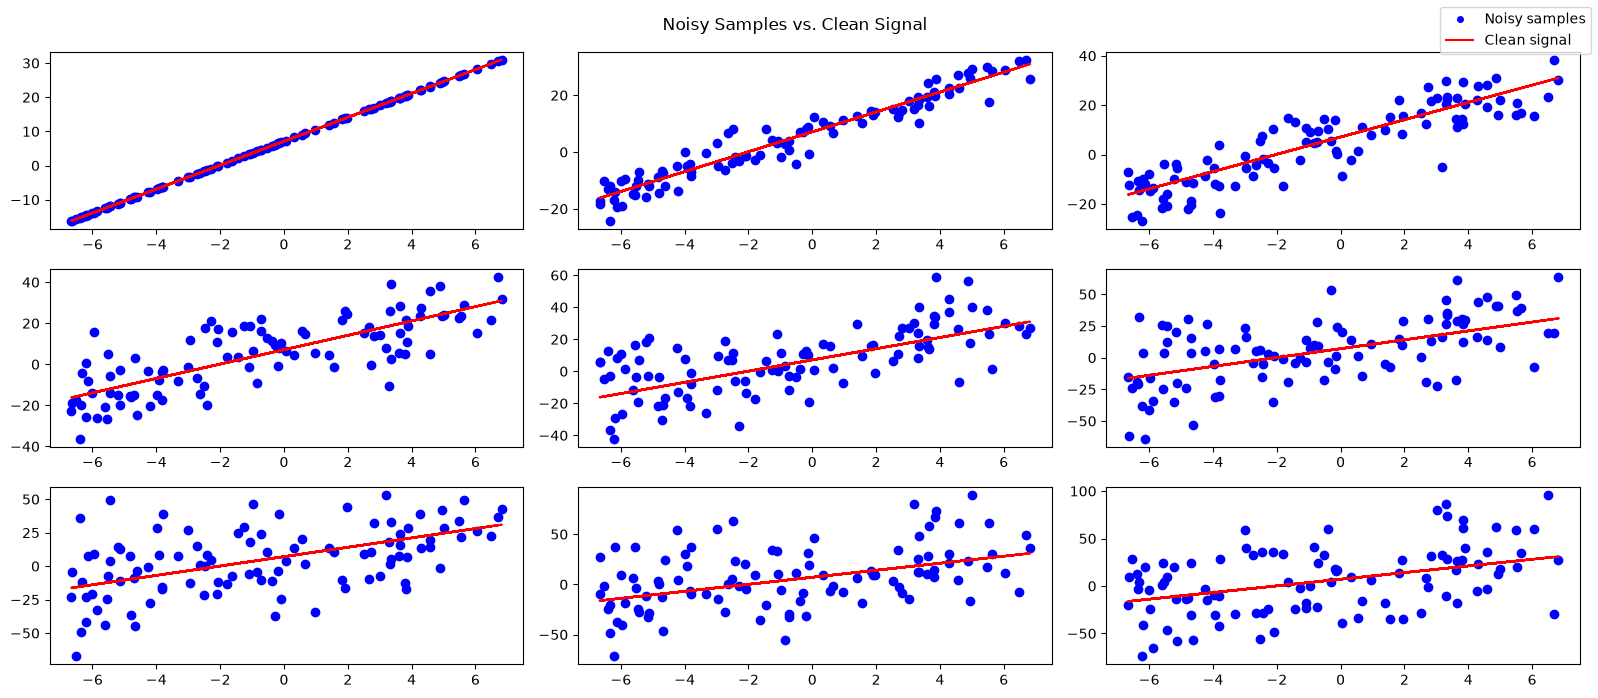

In [73]:
from matplotlib.lines import Line2D

DATASETS_SIZE = 9
SAMPLE_SIZE = 100

X = generate_dataset(size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=30)
X_clean = generate_dataset(size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=0)

fig, axs = generate_axs(X.shape[0])
scatter_dataset(X, fig, axs)
plot_dataset(X_clean, fig, axs)

fig.suptitle("Noisy Samples vs. Clean Signal")
fig.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Noisy samples'),
    Line2D([0], [0], color='red', label='Clean signal'),
], loc='upper right')

fig.tight_layout()
plt.show()

In [ ]:
"""Helpers to create and train a model over a set of samples"""

from core.dataset.dataset import DataLoader, TensorDataset
from core.layers import Linear, Sequential
from core.losses import MSELoss
from core.optimizer import SGD
from core.tensor import Tensor
from core.training.schedulers import CosineSchedule
from core.training.trainer import Trainer

EPOCHS = 500
EVAL_STEP = 10
MAX_LR, MIN_LR = 1e-2, 1e-4

def preprocess_dataloader(sample_tr: np.ndarray, sample_te: np.ndarray, batch_size:int = 1) -> tuple[DataLoader, DataLoader]:
    """Helper to create a DataLoader starting to Numpy arrays"""

    sample_tr_x, sample_tr_y = sample_tr[:, :-1], sample_tr[:, -1].reshape(-1, 1)
    sample_te_x, sample_te_y = sample_te[:, :-1], sample_te[:, -1].reshape(-1, 1)

    data_tr = TensorDataset(Tensor(sample_tr_x), Tensor(sample_tr_y))
    data_te = TensorDataset(Tensor(sample_te_x), Tensor(sample_te_y))

    return DataLoader(data_tr, batch_size), DataLoader(data_te, batch_size)

def split_dataset(X:np.ndarray, split_ratio:float = 0.9, axis:int=0) -> tuple[np.ndarray, np.ndarray]:
    """Split in train and test dataset"""
    
    assert axis < len(X.shape)
    split_idx = int(X.shape[axis]*split_ratio)
    
    X0, X1 = X[:, :split_idx], X[:, split_idx:]

    return X0, X1

def create_trainer(in_feature: int, out_feature:int) -> Trainer:
    """Helper to build model, loss, optimizer, scheduler and finally return the trainer"""

    model = Sequential(
        Linear(in_feature, out_feature)
    )
    loss = MSELoss()
    optimizer = SGD(model.parameters, MAX_LR)
    scheduler = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
    trainer = Trainer(model, loss, optimizer, scheduler)

    return trainer

def fit_model(trainer: Trainer, X_tr: DataLoader, X_te: DataLoader) -> None:
    """Helper to train a model over a sample"""

    for i in range(EPOCHS):
        _ = trainer.train_epoch(X_tr, 1)

        if i % EVAL_STEP == 0:
            _ = trainer.eval(X_te)

def fit_models(trainers: list[Trainer], dataset_tr: np.ndarray, dataset_te: np.ndarray, batch_size: int = 1) -> None:
    """Helper to train a set of models over the complete dataset"""

    for trainer, sample_tr, sample_te in zip(trainers, dataset_tr, dataset_te):        
        sample_tr, sample_te = preprocess_dataloader(sample_tr, sample_te, batch_size)
        fit_model(trainer, sample_tr, sample_te)

## Training the models

First of all, we need to instanciate a model for each dataset with different variance levels. Then, we will train each model using the `fit_models` function.

In [75]:
BATCH_SIZE = 16

trainers: list[Trainer] = []

X_tr, X_te = split_dataset(X, split_ratio=0.9, axis=1)

for i in range(DATASETS_SIZE):
    trainers.append(create_trainer(X.shape[2]-1, X.shape[2]-1))

fit_models(trainers, X_tr, X_te, BATCH_SIZE)

## Loss history

Finally, we will plot the loss history of each model to visualize how variance affects the training process. The training loss will be plotted in blue, while the evaluation loss will be plotted in red.

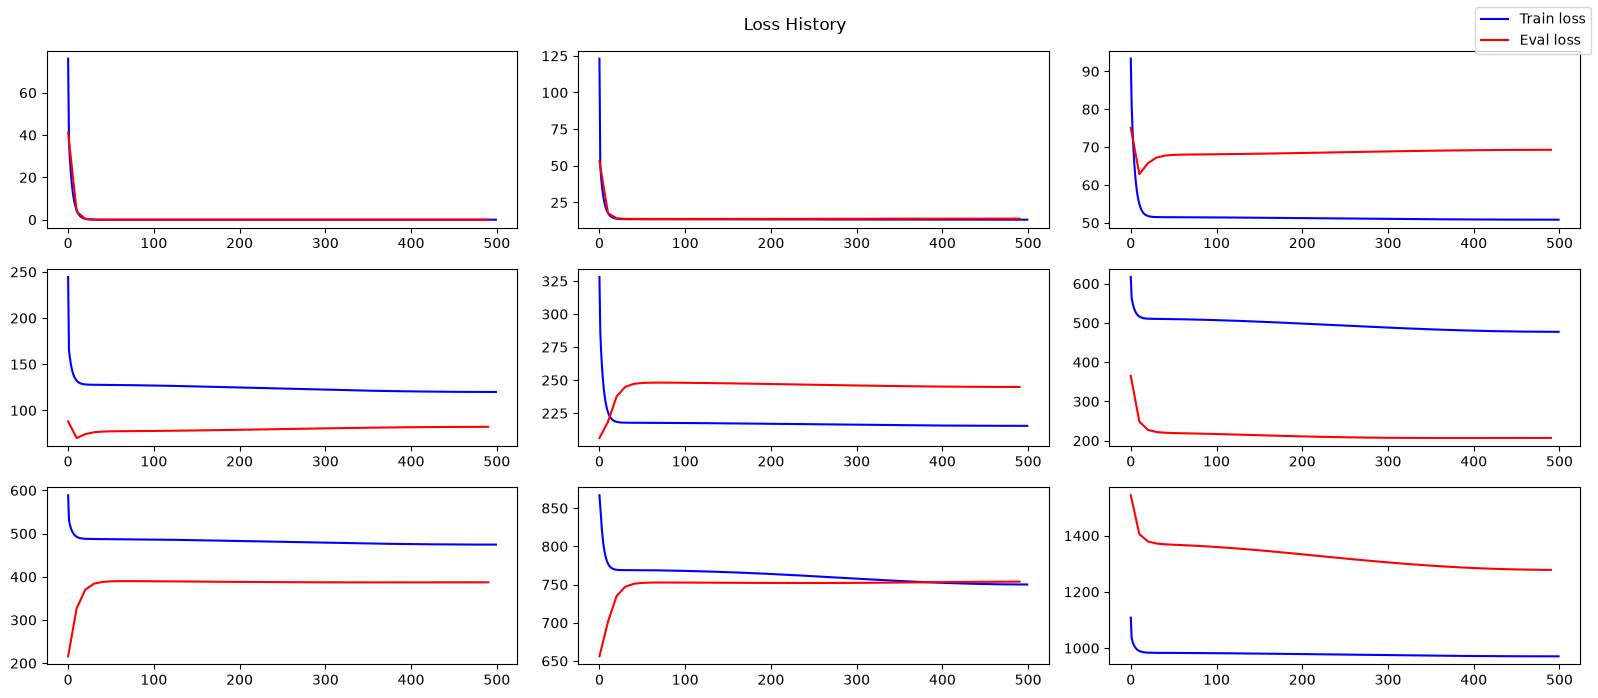

In [76]:
from matplotlib.lines import Line2D

fig, axs = generate_axs(len(trainers))

train_loss_history = []
eval_loss_history = []

for trainer in trainers:
    train_loss_history.append([range(EPOCHS), trainer.train_loss])
    eval_loss_history.append([range(0, EPOCHS, EVAL_STEP), trainer.eval_loss])

train_loss_history = np.array(train_loss_history)
eval_loss_history = np.array(eval_loss_history)

plot_dataset(train_loss_history, fig, axs, color='blue', axis=-1)
plot_dataset(eval_loss_history, fig, axs, color='red', axis=-1)

fig.suptitle("Loss History")
fig.legend(handles=[
    Line2D([0], [0], color='blue', label='Train loss'),
    Line2D([0], [0], color='red', label='Eval loss'),
], loc='upper right')

fig.tight_layout()
plt.show()